In [2]:
import sys
print(sys.executable)

c:\Users\anshi\OneDrive\Desktop\StartupAtlas\StartupAtlas\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded")

All libraries loaded


In [4]:
df = pd.read_csv("../data/raw/investments_VC.csv", encoding="latin1")

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df["status"].value_counts()

status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64

In [7]:
status_pct = (
    df["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_pct)

status
operating    86.92
acquired      7.67
closed        5.41
Name: proportion, dtype: float64


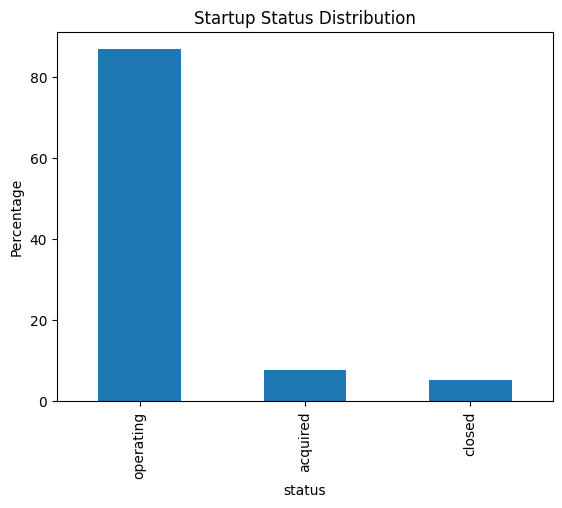

In [8]:
status_pct.plot(kind="bar")
plt.title("Startup Status Distribution")
plt.ylabel("Percentage")
plt.show()

## Key Insight

- Most startups in the dataset are still operating (86.92%).
- Around 7.67% of startups were acquired.
- Around 5.41% of startups have closed down.
- The dataset is highly imbalanced, with operating startups dominating the sample.

In [9]:
acquired_df = df[df["status"] == "acquired"]

top_acquired_markets = (
    acquired_df["market"]
    .value_counts()
    .head(15)
)

top_acquired_markets

market
Software                464
Curated Web             206
Enterprise Software     200
Mobile                  198
Biotechnology           183
Advertising             130
Games                   107
E-Commerce               99
Semiconductors           89
Security                 88
Web Hosting              85
Hardware + Software      75
Health Care              67
Social Media             66
Finance                  60
Name: count, dtype: int64

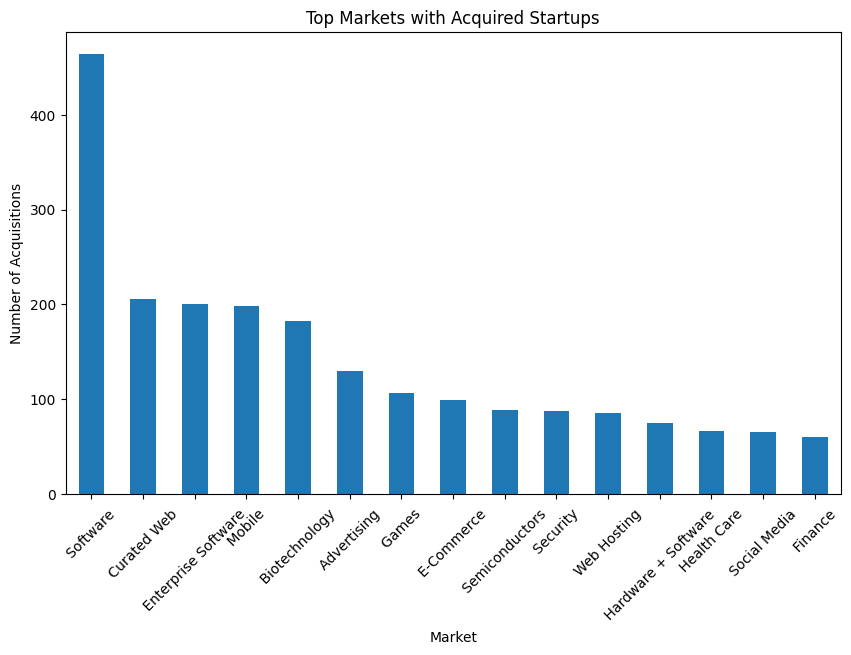

In [10]:
plt.figure(figsize=(10,6))

top_acquired_markets.plot(kind="bar")

plt.title("Top Markets with Acquired Startups")
plt.xlabel("Market")
plt.ylabel("Number of Acquisitions")

plt.xticks(rotation=45)
plt.show()

## Key Insight: Acquired Startup Markets

- Software startups have the highest number of acquisitions.
- Curated Web, Enterprise Software, and Mobile are also strong acquisition sectors.
- Technology-focused industries dominate successful startup exits.
- Markets such as Finance and Health Care show fewer acquisitions compared to software-related sectors.

In [11]:
acquired_countries = (
    acquired_df["country_code"]
    .value_counts()
    .head(15)
)

acquired_countries

country_code
USA    2785
GBR     141
CAN     103
DEU      73
ISR      60
FRA      47
CHN      25
ESP      24
IND      17
IRL      17
NLD      14
DNK      13
SWE      12
AUS      12
ITA      12
Name: count, dtype: int64

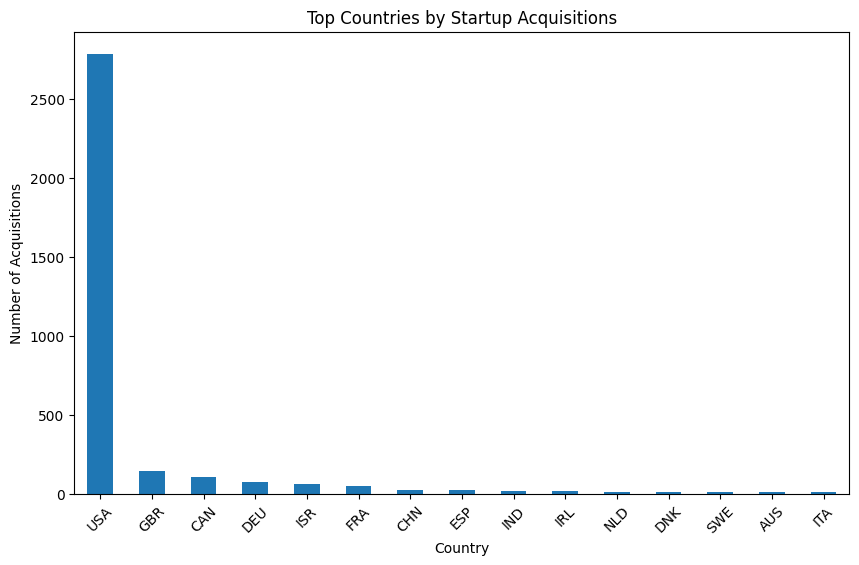

In [12]:
plt.figure(figsize=(10,6))

acquired_countries.plot(kind="bar")

plt.title("Top Countries by Startup Acquisitions")
plt.xlabel("Country")
plt.ylabel("Number of Acquisitions")

plt.xticks(rotation=45)
plt.show()

## Key Insight: Countries with the Most Startup Acquisitions

- The USA dominates startup acquisitions by a very large margin.
- The UK and Canada are distant second and third.
- Most acquisition activity is concentrated in developed startup ecosystems.
- The United States appears to be the primary hub for startup exits and acquisitions in this dataset.

In [13]:
country_stats = pd.crosstab(
    df["country_code"],
    df["status"]
)

country_stats["acquisition_rate"] = (
    country_stats["acquired"]
    / country_stats.sum(axis=1)
    * 100
)

top_rates = (
    country_stats[country_stats.sum(axis=1) >= 50]
    .sort_values("acquisition_rate", ascending=False)
    .head(15)
)

top_rates["acquisition_rate"]

country_code
MAF    100.000000
USA      9.864343
ISR      8.849558
DEU      7.774228
CAN      7.623982
DNK      6.220096
NOR      6.185567
BEL      6.164384
ARE      6.060606
FIN      5.789474
IRL      5.610561
FRA      5.548996
GBR      5.433526
CHE      5.116279
AUT      4.901961
Name: acquisition_rate, dtype: float64

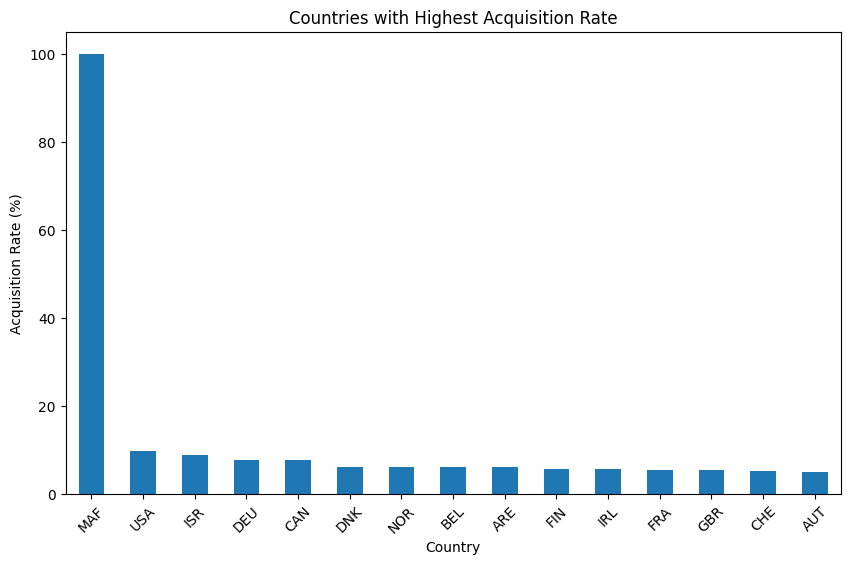

In [14]:
plt.figure(figsize=(10,6))

top_rates["acquisition_rate"].plot(kind="bar")

plt.title("Countries with Highest Acquisition Rate")
plt.ylabel("Acquisition Rate (%)")
plt.xlabel("Country")

plt.xticks(rotation=45)
plt.show()

In [15]:
country_stats["total_startups"] = country_stats.sum(axis=1)

top_rates = (
    country_stats[country_stats["total_startups"] >= 100]
    .sort_values("acquisition_rate", ascending=False)
    .head(15)
)

top_rates[["total_startups", "acquisition_rate"]]

status,total_startups,acquisition_rate
country_code,,
MAF,101.000000,100.000000
USA,28242.864343,9.864343
ISR,686.849558,8.849558
DEU,946.774228,7.774228
CAN,1358.623982,7.623982
DNK,215.220096,6.220096
NOR,103.185567,6.185567
BEL,152.164384,6.164384
FIN,195.789474,5.789474


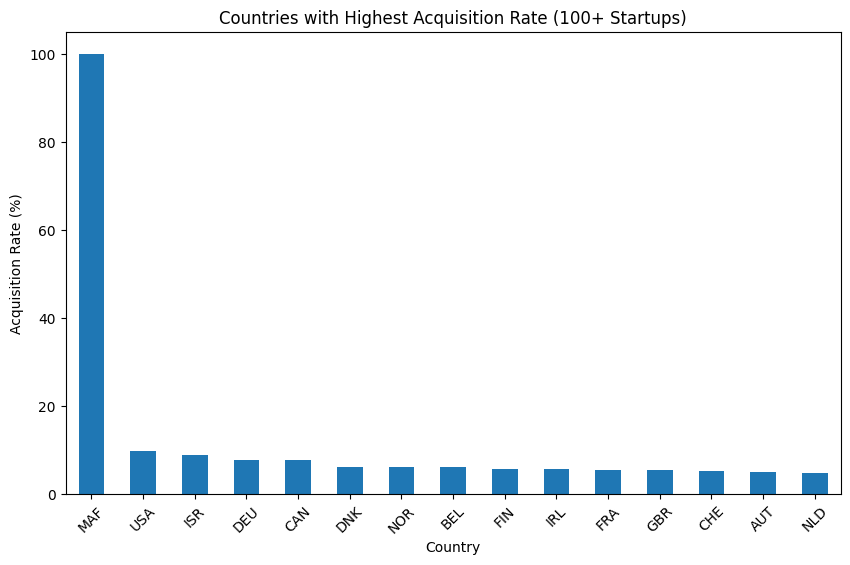

In [16]:
plt.figure(figsize=(10,6))

top_rates["acquisition_rate"].plot(kind="bar")

plt.title("Countries with Highest Acquisition Rate (100+ Startups)")
plt.ylabel("Acquisition Rate (%)")
plt.xlabel("Country")

plt.xticks(rotation=45)
plt.show()

In [17]:
country_stats = pd.crosstab(
    df["country_code"],
    df["status"]
)

country_stats["total_startups"] = (
    country_stats["operating"]
    + country_stats["acquired"]
    + country_stats["closed"]
)

country_stats["acquisition_rate"] = (
    country_stats["acquired"]
    / country_stats["total_startups"]
    * 100
)

top_rates = (
    country_stats[country_stats["total_startups"] >= 100]
    .sort_values("acquisition_rate", ascending=False)
    .head(15)
)

top_rates[["total_startups", "acquisition_rate"]]

status,total_startups,acquisition_rate
country_code,,
USA,28233,9.864343
ISR,678,8.849558
DEU,939,7.774228
CAN,1351,7.623982
DNK,209,6.220096
BEL,146,6.164384
FIN,190,5.789474
IRL,303,5.610561
FRA,847,5.548996


In [18]:
df[df["country_code"] == "MAF"]["status"].value_counts()

status
acquired    1
Name: count, dtype: int64

In [19]:
df[df["country_code"] == "MAF"].shape

(1, 39)

## Key Insight: Countries with the Highest Startup Acquisition Rates

Initial analysis showed **MAF** with a 100% acquisition rate. However, further investigation revealed that this result was based on only **one startup**, which had been acquired.

This highlights an important data analysis principle: **percentages can be misleading when the sample size is very small.**

To obtain more reliable insights, countries with very few startups were excluded from the analysis.

### Findings

- The **United States (USA)** recorded the highest number of startup acquisitions overall.
- **Israel (ISR)** showed one of the strongest acquisition rates among countries with a substantial startup ecosystem.
- **Germany (DEU)** and **Canada (CAN)** also demonstrated relatively high acquisition rates.
- Countries with small startup populations can produce artificially inflated acquisition rates and should be interpreted cautiously.

### Conclusion

When evaluating startup success across countries, acquisition rates should always be considered alongside the total number of startups. Countries with larger startup ecosystems provide more reliable indicators of acquisition performance than countries with only a handful of startups.

# Funding vs Startup Outcome

### Business Question

Do acquired startups generally raise more funding than closed startups?

### Why This Matters

Funding is one of the most important signals of startup growth and investor confidence.

This analysis compares funding levels across different startup outcomes to identify whether successful startups tend to raise more capital.

### Method

- Group startups by status
- Compare median funding amounts
- Visualize differences between operating, acquired, and closed startups

In [21]:
df["funding_total_usd"].dtype

<StringDtype(storage='python', na_value=nan)>

In [22]:
df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

In [23]:
df["funding_total_usd"].dtype

dtype('float64')

In [24]:
status_funding = (
    df.groupby("status")["funding_total_usd"]
    .median()
    .sort_values(ascending=False)
)

status_funding

status
operating    291.0
acquired       NaN
closed         NaN
Name: funding_total_usd, dtype: float64

In [25]:
df.groupby("status")["funding_total_usd"].count()

status
acquired      0
closed        0
operating    41
Name: funding_total_usd, dtype: int64

In [27]:
df.groupby("status").agg(
    total_rows=("funding_total_usd", "size"),
    non_null_funding=("funding_total_usd", "count")
)

,total_rows,non_null_funding
status,,
acquired,3692,0
closed,2603,0
operating,41829,41


In [28]:
df["funding_total_usd"].describe()

count     42.000000
mean     329.309524
std      286.158023
min        1.000000
25%      100.000000
50%      253.000000
75%      500.000000
max      929.000000
Name: funding_total_usd, dtype: float64

In [29]:
df["funding_total_usd"].notna().sum()

np.int64(42)

In [30]:
df[["status", "funding_total_usd"]].sample(10)

,status,funding_total_usd
1990,closed,NaN
25258,operating,NaN
30785,operating,NaN
33041,operating,NaN
25468,operating,NaN
34996,operating,NaN
18890,operating,NaN
34447,operating,NaN
1777,operating,NaN
6292,operating,NaN


In [31]:
df["funding_total_usd"].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: funding_total_usd, dtype: float64

In [32]:
df["funding_total_usd"].dropna().head(20)

2766     100.0
3313     100.0
4850     144.0
4869     215.0
5533     100.0
8816     929.0
9016     300.0
9330     150.0
9424     500.0
10237    827.0
11245      1.0
11921    600.0
12702    102.0
13242    500.0
13772     22.0
14745    123.0
16864    100.0
17794    500.0
18328    100.0
19178    700.0
Name: funding_total_usd, dtype: float64

In [33]:
df = pd.read_csv(
    "../data/raw/investments_VC.csv",
    encoding="latin1"
)

df.columns = df.columns.str.strip()

In [34]:
df["funding_total_usd"].head(20)

0      17,50,000 
1      40,00,000 
2         40,000 
3      15,00,000 
4         60,000 
5      70,00,000 
6      49,12,393 
7      20,00,000 
8            -   
9         41,250 
10        40,000 
11           -   
12           -   
13     17,50,000 
14           -   
15     44,00,000 
16     20,50,000 
17        40,000 
18      5,00,000 
19           -   
Name: funding_total_usd, dtype: str

In [35]:
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

In [36]:
df["funding_total_usd"].notna().sum()

np.int64(40907)

In [37]:
status_funding = (
    df.groupby("status")["funding_total_usd"]
    .median()
    .sort_values(ascending=False)
)

status_funding

status
acquired     8382400.0
operating    1757977.5
closed       1000000.0
Name: funding_total_usd, dtype: float64

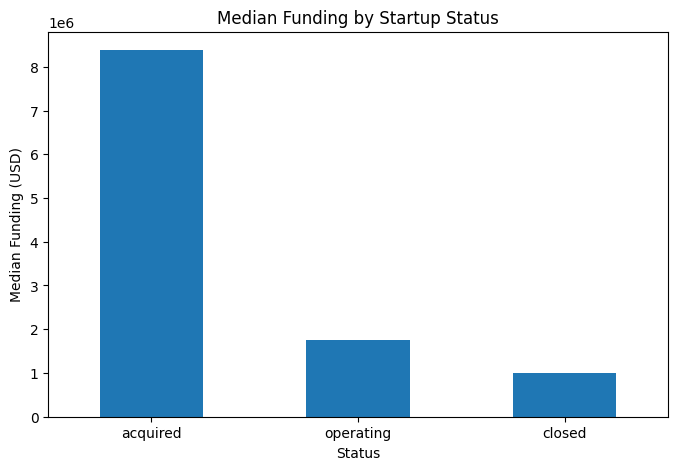

In [38]:
plt.figure(figsize=(8,5))

status_funding.plot(kind="bar")

plt.title("Median Funding by Startup Status")
plt.xlabel("Status")
plt.ylabel("Median Funding (USD)")

plt.xticks(rotation=0)

plt.show()

## Key Insight: Funding vs Startup Outcome

This analysis compares the median funding raised by startups based on their current status.

### Findings

- Acquired startups have the highest median funding, at approximately **$8.4 million**.
- Operating startups have a median funding of approximately **$1.8 million**.
- Closed startups have the lowest median funding, at approximately **$1.0 million**.

### Interpretation

The results suggest a strong relationship between funding and startup outcomes.

Acquired startups tend to attract substantially more investment than both operating and closed startups. Higher funding may provide startups with greater resources for growth, product development, market expansion, and talent acquisition, increasing their chances of becoming attractive acquisition targets.

Closed startups, on the other hand, generally raise less capital, which may limit their ability to scale and compete effectively.

### Conclusion

Funding appears to be an important indicator of startup success. Startups that secure larger amounts of investment are more likely to achieve successful outcomes such as acquisitions.

# Funding Rounds vs Startup Outcome

### Business Question

Do successful startups typically complete more funding rounds than unsuccessful startups?

### Why This Matters

Funding rounds reflect continued investor confidence and startup growth.

Analyzing funding rounds can help determine whether startups with successful outcomes tend to receive multiple rounds of investment.

In [39]:
status_rounds = (
    df.groupby("status")["funding_rounds"]
    .median()
    .sort_values(ascending=False)
)

status_rounds

status
acquired     2.0
closed       1.0
operating    1.0
Name: funding_rounds, dtype: float64

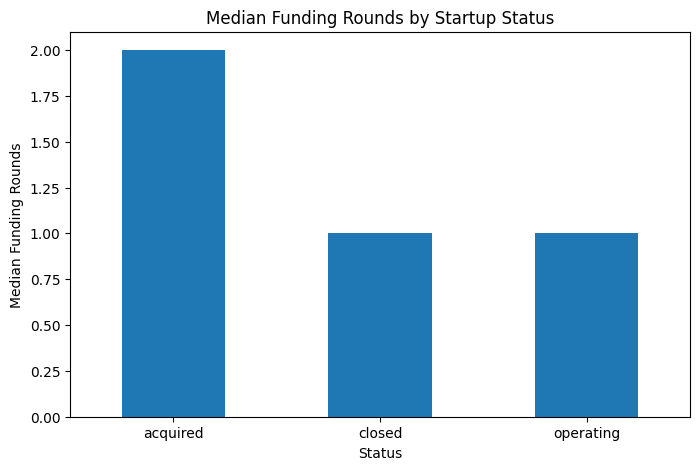

In [40]:
plt.figure(figsize=(8,5))

status_rounds.plot(kind="bar")

plt.title("Median Funding Rounds by Startup Status")
plt.xlabel("Status")
plt.ylabel("Median Funding Rounds")

plt.xticks(rotation=0)

plt.show()

## Key Insight: Funding Rounds vs Startup Outcome

This analysis compares the median number of funding rounds completed by startups based on their current status.

### Findings

- Acquired startups have a median of **2 funding rounds**.
- Operating startups have a median of **1 funding round**.
- Closed startups also have a median of **1 funding round**.

### Interpretation

The results suggest that startups which achieve acquisitions generally progress through more funding rounds than other startups.

Multiple funding rounds may indicate:
- Continued investor confidence
- Strong business growth
- Increased market traction
- Greater operational maturity

In contrast, both operating and closed startups typically complete only one funding round, suggesting more limited access to capital.

### Conclusion

Funding rounds appear to be another important indicator of startup success. Startups that secure multiple rounds of investment are more likely to reach successful outcomes such as acquisitions.

# Final Conclusions

## Major Findings

### 1. Startup Status Distribution
- Most startups in the dataset are currently operating.
- Acquired startups represent a smaller but significant portion of the ecosystem.

### 2. Acquisition Markets
- Software, Mobile, and Enterprise Software are among the most acquisition-heavy markets.
- Technology-driven sectors dominate successful exits.

### 3. Country Analysis
- The United States records the highest number of startup acquisitions.
- Countries such as Israel and Germany also demonstrate strong acquisition performance.

### 4. Funding and Success
- Acquired startups raise significantly more funding than operating and closed startups.
- Higher funding levels are strongly associated with successful outcomes.

### 5. Funding Rounds and Success
- Acquired startups typically complete more funding rounds.
- Multiple funding rounds may reflect stronger investor confidence and business growth.

## Overall Conclusion

The analysis suggests that startup success is associated with both higher funding amounts and a greater number of funding rounds. Technology-focused markets and mature startup ecosystems also appear to contribute to successful acquisition outcomes.